# Exercício 5

## Carregamento e Tratamento dos dados 

In [107]:
import pandas as pd 

df = pd.read_csv("../data/IMDB Dataset.csv")
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [108]:
import re
import string

def lower_case(text):
    return text.lower()

def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['review'] = df['review'].apply(lower_case)
df['review'] = df['review'].apply(remove_html_tags)
df['review'] = df['review'].apply(remove_punctuation)

df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


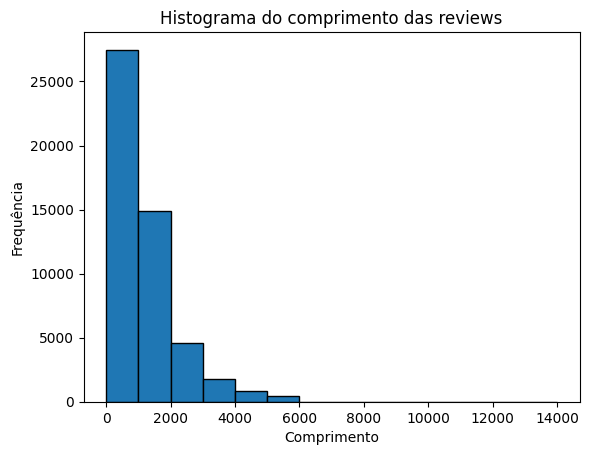

In [109]:
import matplotlib.pyplot as plt

review_len = []
for review in df['review']:
    review_len.append(len(review))

max_len = max(review_len)
bins = range(0, int(max_len) + 1000, 1000)

plt.hist(review_len, bins=bins, edgecolor='black')
plt.title('Histograma do comprimento das reviews')
plt.xlabel('Comprimento')
plt.ylabel('Frequência')
plt.show()

In [110]:
def cap_text(text):
  if len(text) <= 1000:
    return text
  return text[:1000].rsplit(' ', 1)[0]

df['review'] = df['review'].apply(cap_text)

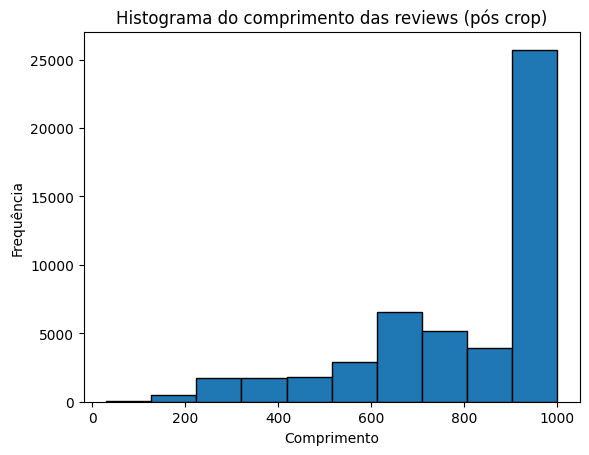

In [111]:
import matplotlib.pyplot as plt

review_len = []
for review in df['review']:
    review_len.append(len(review))

plt.hist(review_len, bins=10, edgecolor='black')
plt.title('Histograma do comprimento das reviews (pós crop)')
plt.xlabel('Comprimento')
plt.ylabel('Frequência')
plt.show()

In [112]:
print(df.iloc[0].review)

one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty


### Remoção de stopwords e lemmatization

In [113]:
import spacy

nlp = spacy.load("en_core_web_sm")

def remove_stopwords(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if not token.is_stop])

texts = df['review'].tolist()
processed = []
for doc in nlp.pipe(texts, batch_size=500, disable=["parser", "ner"]):
    processed.append(' '.join([token.lemma_ for token in doc if not token.is_stop]))

df['review'] = processed
df.head()

,review,sentiment
0,reviewer mention watch 1 oz episode ll hook ri...,positive
1,wonderful little production filming technique ...,positive
2,think wonderful way spend time hot summer week...,positive
3,basically s family little boy jake think s zom...,negative
4,petter matteis love time money visually stunni...,positive


## Tokenização, Vocabulário e Padding

In [114]:
def tokenize(text):
    return text.split()

In [115]:
from collections import Counter

counter = Counter()

for text in df["review"]:
    counter.update(tokenize(text))

vocab_size = 20000

most_common = counter.most_common(vocab_size)

word2idx = {
    "<pad>": 0,
    "<unk>": 1
}

for i, (word, _) in enumerate(most_common, start=2):
    word2idx[word] = i

def encode(text):

    tokens = tokenize(text)

    return [
        word2idx.get(token, word2idx["<unk>"])
        for token in tokens
    ]

In [116]:
max_len = 256
def pad_sequence(ids):
    ids = ids[:max_len]
    if len(ids) < max_len:
        ids = [word2idx["<pad>"]] * (max_len - len(ids)) + ids 
    return ids

In [117]:
import torch
from torch.utils.data import Dataset

class IMDBDataset(Dataset):
    def __init__(self, df):
        self.texts = df["review"].tolist()

        self.labels = df["sentiment"].map({
            "negative":0,
            "positive":1
        }).tolist()
        
    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts[idx])
        ids = pad_sequence(ids)

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

In [118]:
from torch.utils.data import DataLoader

dataset = IMDBDataset(df)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [119]:
#batch com 128 reviews e cada uma com 128 tokens
for x, y in loader:
    print(x.shape)
    print(y.shape)

    break

torch.Size([128, 256])
torch.Size([128])


## Train/Test Split e DataLoaders

In [120]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.5,
    random_state=42,
    stratify=df["sentiment"]
)

train_dataset = IMDBDataset(train_df)
test_dataset = IMDBDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Treino: {len(train_dataset)} amostras")
print(f"Teste: {len(test_dataset)} amostras")

Treino: 25000 amostras
Teste: 25000 amostras


## Modelo LSTM

In [121]:
import torch
import torch.nn as nn

class LSTMManual(nn.Module):
    def __init__(self, input_dim, hidden_dim):

        super().__init__()

        self.hidden_dim = hidden_dim

        self.W_f = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.W_i = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.W_g = nn.Linear(input_dim + hidden_dim, hidden_dim)
        self.W_o = nn.Linear(input_dim + hidden_dim, hidden_dim)

        nn.init.constant_(self.W_f.bias, 1.0)

    def forward(self, x):

        batch_size, seq_len, input_dim = x.size()

        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)
        c = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        for t in range(seq_len):

            x_t = x[:, t, :]

            combined = torch.cat((h, x_t), dim=1)

            f = torch.sigmoid(self.W_f(combined))
            i = torch.sigmoid(self.W_i(combined))
            g = torch.tanh(self.W_g(combined))
            o = torch.sigmoid(self.W_o(combined))

            c = f * c + i * g
            h = o * torch.tanh(c)

        return h

In [122]:
class Model(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = LSTMManual(embed_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.5)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.embedding(x)
        h = self.lstm(x)
        h = self.dropout(h)
        out = self.fc(h)

        return out

## Treinamento

In [123]:
import torch.optim as optim

model = Model(
    vocab_size=len(word2idx),
    embed_dim=64,
    hidden_dim=64
)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [124]:
import numpy as np

epochs = 10

history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

for epoch in range(epochs):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        outputs = model(x).squeeze()
        loss = criterion(outputs, y.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = (outputs >= 0.0).long()
        correct += (preds == y).sum().item()
        total += x.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for x, y in test_loader:
            outputs = model(x).squeeze()
            loss = criterion(outputs, y.float())

            test_loss += loss.item() * x.size(0)
            preds = (outputs >= 0.0).long()
            test_correct += (preds == y).sum().item()
            test_total += x.size(0)

    test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Época {epoch+1}/{epochs} | "
          f"Loss treino: {train_loss:.4f} | Acc treino: {train_acc*100:.2f}% | "
          f"Loss teste: {test_loss:.4f} | Acc teste: {test_acc*100:.2f}%")

Época 1/10 | Loss treino: 0.6167 | Acc treino: 65.41% | Loss teste: 0.5302 | Acc teste: 74.37%
Época 2/10 | Loss treino: 0.4692 | Acc treino: 78.80% | Loss teste: 0.4433 | Acc teste: 79.94%
Época 3/10 | Loss treino: 0.3843 | Acc treino: 83.36% | Loss teste: 0.5149 | Acc teste: 74.42%
Época 4/10 | Loss treino: 0.3533 | Acc treino: 85.42% | Loss teste: 0.4043 | Acc teste: 82.80%
Época 5/10 | Loss treino: 0.2763 | Acc treino: 89.18% | Loss teste: 0.4043 | Acc teste: 83.41%
Época 6/10 | Loss treino: 0.2322 | Acc treino: 91.36% | Loss teste: 0.4082 | Acc teste: 83.68%
Época 7/10 | Loss treino: 0.1969 | Acc treino: 93.06% | Loss teste: 0.4408 | Acc teste: 83.63%
Época 8/10 | Loss treino: 0.1619 | Acc treino: 94.57% | Loss teste: 0.4767 | Acc teste: 83.59%
Época 9/10 | Loss treino: 0.1356 | Acc treino: 95.63% | Loss teste: 0.5114 | Acc teste: 83.36%
Época 10/10 | Loss treino: 0.1097 | Acc treino: 96.70% | Loss teste: 0.5715 | Acc teste: 83.32%


## Curvas de Treinamento e Avaliação

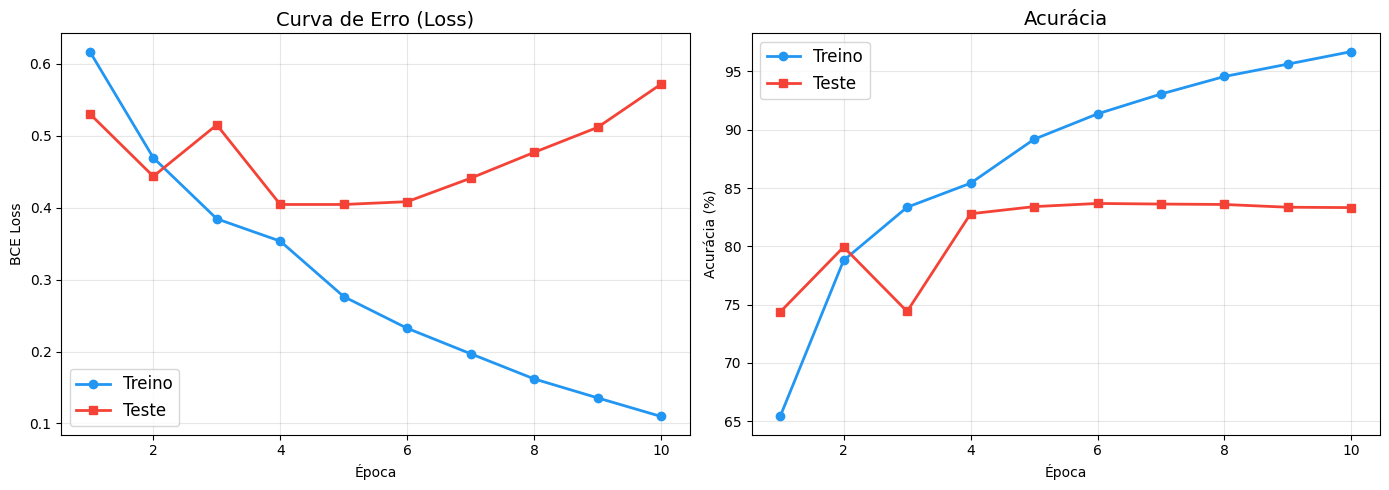

Melhor acurácia de teste: 83.68% (época 6)


In [125]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'o-', color='#2196F3', label='Treino', linewidth=2)
ax1.plot(epochs_range, history['test_loss'], 's-', color='#F44336', label='Teste', linewidth=2)
ax1.set_title('Curva de Erro (Loss)', fontsize=14)
ax1.set_xlabel('Época')
ax1.set_ylabel('BCE Loss')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in history['train_acc']], 'o-', color='#2196F3', label='Treino', linewidth=2)
ax2.plot(epochs_range, [a * 100 for a in history['test_acc']], 's-', color='#F44336', label='Teste', linewidth=2)
ax2.set_title('Acurácia', fontsize=14)
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia (%)')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Melhor acurácia de teste: {max(history['test_acc'])*100:.2f}% (época {np.argmax(history['test_acc'])+1})")

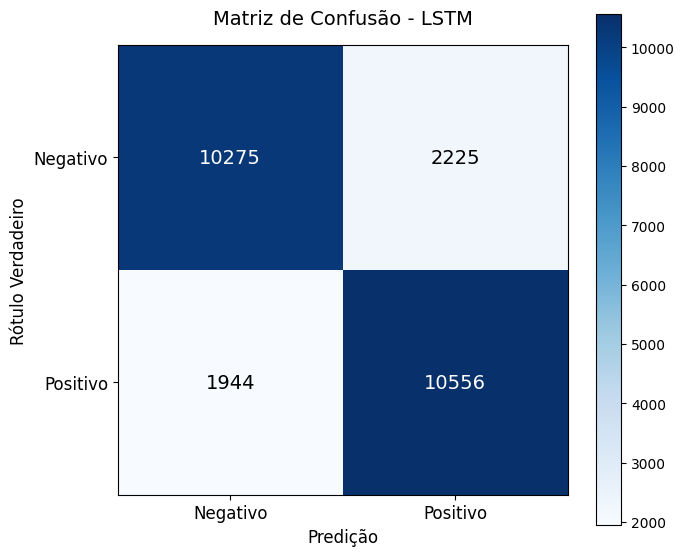

              precision    recall  f1-score   support

    Negativo       0.84      0.82      0.83     12500
    Positivo       0.83      0.84      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000



In [126]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs = model(X_batch).squeeze()
            preds = (outputs >= 0.0).long()
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(y_true, y_pred, classes, title="Matriz de Confusão"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(title, fontsize=14, pad=15)
    plt.colorbar(im, ax=ax)
    tick_marks = range(len(classes))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(classes, fontsize=12)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(classes, fontsize=12)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=14)

    ax.set_ylabel('Rótulo Verdadeiro', fontsize=12)
    ax.set_xlabel('Predição', fontsize=12)
    plt.tight_layout()
    plt.show()

preds, labels = get_predictions(model, test_loader)
plot_confusion_matrix(labels, preds, ['Negativo', 'Positivo'], "Matriz de Confusão - LSTM")
print(classification_report(labels, preds, target_names=['Negativo', 'Positivo']))

## 5 Exemplos de Predição no Conjunto de Teste

In [127]:
idx2word = {idx: word for word, idx in word2idx.items()}

sample_df = test_df.sample(5, random_state=42)

model.eval()
print("=" * 80)
print("5 EXEMPLOS DE PREDIÇÃO NO CONJUNTO DE TESTE")
print("=" * 80)

for i, (idx, row) in enumerate(sample_df.iterrows()):
    ids = pad_sequence(encode(row['review']))
    x_sample = torch.tensor(ids, dtype=torch.long).unsqueeze(0)

    with torch.no_grad():
        logit = model(x_sample)
        prob = torch.sigmoid(logit).item()

    pred_label = "Positivo" if prob >= 0.5 else "Negativo"
    true_label = "Positivo" if row['sentiment'] == "positive" else "Negativo"
    status = "✓" if pred_label == true_label else "✗"

    print(f"\n{'─' * 80}")
    print(f"Exemplo {i+1} {status}")
    print(f"Review: \"{row['review'][:200]}...\"")
    print(f"Rótulo verdadeiro: {true_label}")
    print(f"Predição: {pred_label} (prob positivo: {prob:.4f})")
print(f"\n{'─' * 80}")

5 EXEMPLOS DE PREDIÇÃO NO CONJUNTO DE TESTE

────────────────────────────────────────────────────────────────────────────────
Exemplo 1 ✓
Review: "de dominee base life real dutch gangsterklaas bruinsma movie call klaas donker doubt event present movie happen not matter fail grab attention movie bore crap lack substance style substance forgive ac..."
Rótulo verdadeiro: Negativo
Predição: Negativo (prob positivo: 0.0035)

────────────────────────────────────────────────────────────────────────────────
Exemplo 2 ✓
Review: "people ability use 3 neuron eat breathing ste movie enjoy brain movie metaphor purpose single detail coffee mug red couch underestimated masterpiece hilarious raw totally realistic s actually interact..."
Rótulo verdadeiro: Positivo
Predição: Positivo (prob positivo: 0.9596)

────────────────────────────────────────────────────────────────────────────────
Exemplo 3 ✓
Review: "powerful film rearisen joe mccarthy censorship period influence jewish teenager friend color fa